<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_2_LogisticRegression/18_2_1_LogReg_Intro_w_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification: Logistic Regression
## Introduction with Titanic

**Author:** Brad Sheese

---

## Introduction

In Module 18_1 we trained XGBoost to classify credit applicants and detect fraud. XGBoost is powerful, but it is a black box: when it predicts that a passenger will die, it cannot tell you *why* in terms a doctor, a judge, or a regulator can audit.

Logistic regression solves that problem. It produces the same kind of probability output as XGBoost, but every prediction can be traced back to a signed, interpretable coefficient. It is also — not coincidentally — the mathematical core of every artificial neuron ever built. When you understand logistic regression fully, you already understand one third of what makes a neural network work.

In this notebook we build a logistic regression model on the Titanic dataset, interpret its coefficients as odds ratios, and develop a clear sense of when you would choose it over more powerful but less transparent alternatives.

### Learning Objectives

By the end of this notebook you will be able to:
1. Explain how the sigmoid function converts a linear combination of features into a probability.
2. Describe logistic regression as a single artificial neuron, connecting it to neural network architecture.
3. Build a logistic regression pipeline in sklearn with correct preprocessing and no data leakage.
4. Interpret model coefficients as odds ratios and explain them in plain language.
5. Evaluate the model using precision, recall, AUC, and threshold tuning.
6. Articulate when logistic regression is a better choice than XGBoost or a neural network.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.metrics import precision_score, recall_score, accuracy_score, precision_recall_curve, average_precision_score

sns.set_theme(style="whitegrid")

## Load and Explore the Data

Before building any model, we should understand our data. The Titanic dataset contains passenger information: class, sex, age, family details, and fare. Let's load it and see what we're working with.

In [2]:
url = 'https://raw.githubusercontent.com/bsheese/cs377/main/data/data_titanic.csv'
df = pd.read_csv(url)

df.columns = df.columns.str.lower().str.replace(' aboard', '', regex=False)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   survived          887 non-null    int64  
 1   pclass            887 non-null    int64  
 2   name              887 non-null    str    
 3   sex               887 non-null    str    
 4   age               887 non-null    float64
 5   siblings/spouses  887 non-null    int64  
 6   parents/children  887 non-null    int64  
 7   fare              887 non-null    float64
dtypes: float64(2), int64(4), str(2)
memory usage: 81.6 KB


### Exploratory Data Analysis

Let's visualize how survival relates to key features. The cultural memory of Titanic is "women and children first" — does the data support this?

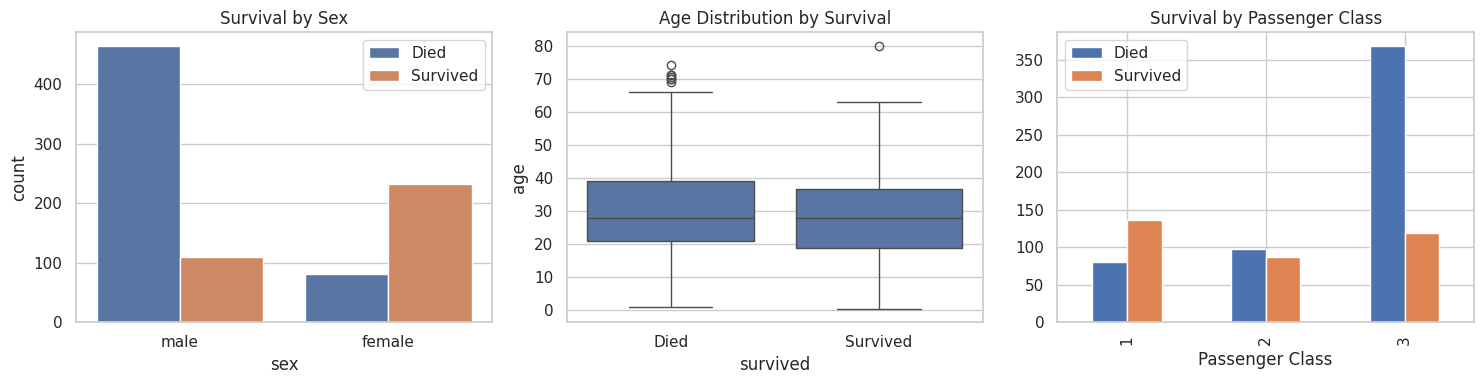

Survival rate by sex:
sex
female    0.742038
male      0.190227
Name: survived, dtype: float64

Survival rate by class:
pclass
1    0.629630
2    0.472826
3    0.244353
Name: survived, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=df, x='sex', hue='survived', ax=axes[0])
axes[0].set_title('Survival by Sex')
axes[0].legend(['Died', 'Survived'])

sns.boxplot(data=df, x='survived', y='age', ax=axes[1])
axes[1].set_title('Age Distribution by Survival')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Died', 'Survived'])

pd.crosstab(df['pclass'], df['survived']).plot(kind='bar', ax=axes[2])
axes[2].set_title('Survival by Passenger Class')
axes[2].legend(['Died', 'Survived'])
axes[2].set_xlabel('Passenger Class')

plt.tight_layout()
plt.show()

print("Survival rate by sex:")
print(df.groupby('sex')['survived'].mean())
print("\nSurvival rate by class:")
print(df.groupby('pclass')['survived'].mean())

**Observations:**
- **Sex** is a strong predictor: women survived at a much higher rate than men
- **Age** shows a slight trend — younger passengers may have had better survival odds
- **Passenger class** matters: 1st class passengers survived at a much higher rate than 3rd class

Note the **class imbalance**: about 62% of passengers died, 38% survived. We'll come back to this.

## How Logistic Regression Works

Before we build the model, we need to understand the two mathematical pieces that make logistic regression different from linear regression — and that will reappear every time you study neural networks.

### The Problem with a Straight Line

Linear regression predicts a number: $\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots$

For classification we want a *probability* between 0 and 1. A straight line won't stay bounded: it could predict a survival probability of 2.3 or −0.4, which are nonsensical. We need to squash its output into $[0, 1]$.

### The Sigmoid Function

The sigmoid (logistic) function does exactly this:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Feed it any real number $z$ and it returns a value strictly between 0 and 1. At $z = 0$ the output is 0.5 — maximum uncertainty. Large positive $z$ → output approaches 1 (almost certainly survived). Large negative $z$ → output approaches 0 (almost certainly died).

In logistic regression, $z$ is our familiar linear combination:

$$z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_k x_k$$

So the full model is: $P(\text{survive}) = \sigma(\beta_0 + \beta_1 x_1 + \ldots)$

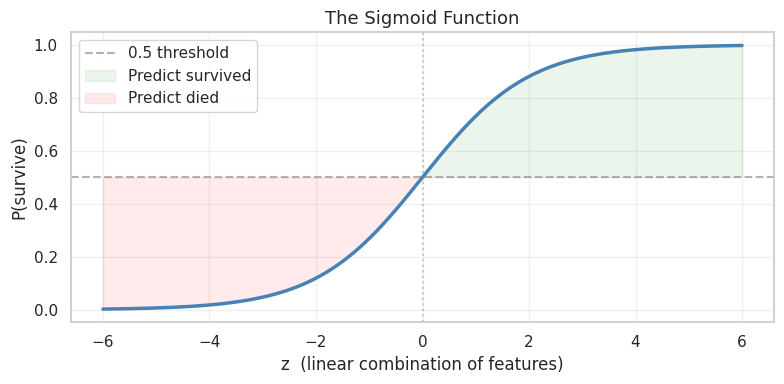

In [4]:
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-6, 6, 300)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 4))
plt.plot(z, sigmoid, 'steelblue', lw=2.5)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='0.5 threshold')
plt.axvline(0, color='gray', linestyle=':', alpha=0.4)
plt.fill_between(z, sigmoid, 0.5, where=(z >= 0), alpha=0.08, color='green', label='Predict survived')
plt.fill_between(z, sigmoid, 0.5, where=(z <= 0), alpha=0.08, color='red', label='Predict died')
plt.xlabel('z  (linear combination of features)', fontsize=12)
plt.ylabel('P(survive)', fontsize=12)
plt.title('The Sigmoid Function', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### This Is Already a Neural Network

Look at what logistic regression is doing step by step:

1. **Weighted inputs**: multiply each feature by a learned weight $\beta_j$
2. **Sum with a bias**: add them up: $z = \beta_0 + \beta_1 x_1 + \ldots$
3. **Activation function**: pass $z$ through the sigmoid to get a probability

This is the exact structure of one artificial neuron. In neural network vocabulary: the $\beta$ coefficients are *weights*, $\beta_0$ is the *bias*, and the sigmoid is the *activation function*. A deep neural network is millions of these neurons stacked in layers — but the core unit is identical to what we are building right now.

The diagram below shows this explicitly.

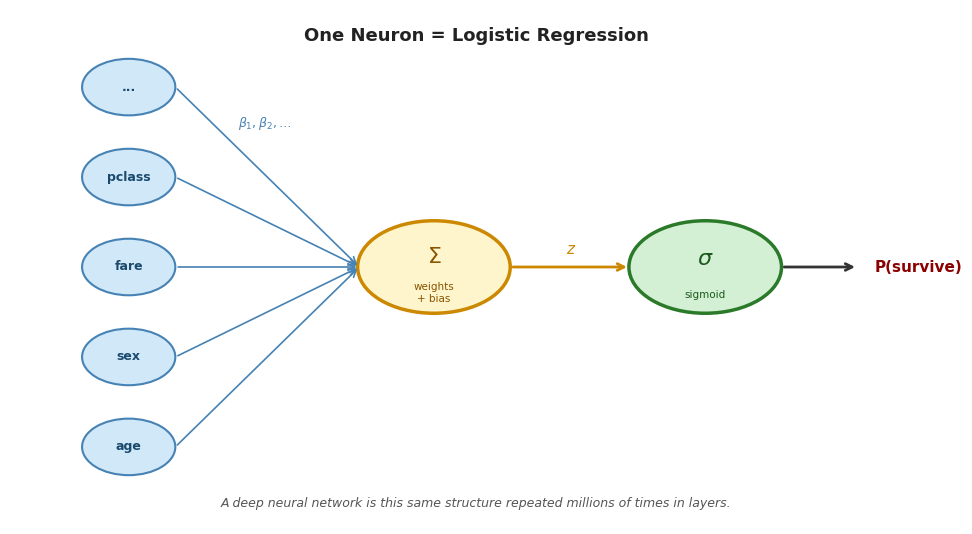

In [5]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.set_xlim(0, 11)
ax.set_ylim(0, 10)
ax.axis('off')

# Input nodes
feature_labels = ['age', 'sex', 'fare', 'pclass', '...']
ys = np.linspace(1.5, 8.5, len(feature_labels))
for label, y in zip(feature_labels, ys):
    c = plt.Circle((1.4, y), 0.55, color='#d0e8f7', ec='steelblue', lw=1.5, zorder=3)
    ax.add_patch(c)
    ax.text(1.4, y, label, ha='center', va='center', fontsize=9, fontweight='bold', color='#1a4a6e')

# Summation node
c_sum = plt.Circle((5, 5), 0.9, color='#fff5cc', ec='#cc8800', lw=2.5, zorder=3)
ax.add_patch(c_sum)
ax.text(5, 5.2, r'$\Sigma$', ha='center', va='center', fontsize=16, color='#885500')
ax.text(5, 4.5, 'weights\n+ bias', ha='center', va='center', fontsize=7.5, color='#885500')

# Sigmoid node
c_sig = plt.Circle((8.2, 5), 0.9, color='#d4f0d4', ec='#2a7a2a', lw=2.5, zorder=3)
ax.add_patch(c_sig)
ax.text(8.2, 5.15, r'$\sigma$', ha='center', va='center', fontsize=16, color='#1a5a1a')
ax.text(8.2, 4.45, 'sigmoid', ha='center', va='center', fontsize=7.5, color='#1a5a1a')

# Output arrow and label
ax.annotate('', xy=(10.0, 5), xytext=(9.1, 5),
            arrowprops=dict(arrowstyle='->', color='#333', lw=2))
ax.text(10.2, 5, 'P(survive)', ha='left', va='center', fontsize=11,
        fontweight='bold', color='#8b0000')

# Arrows: inputs → sum
for y in ys:
    ax.annotate('', xy=(4.12, 5), xytext=(1.95, y),
                arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.2))

# Arrow: sum → sigmoid
ax.annotate('', xy=(7.31, 5), xytext=(5.9, 5),
            arrowprops=dict(arrowstyle='->', color='#cc8800', lw=2))
ax.text(6.6, 5.35, 'z', ha='center', va='center', fontsize=11,
        fontstyle='italic', color='#cc8800')

# Weight labels on input arrows
ax.text(3.0, 7.8, r'$\beta_1, \beta_2, \ldots$', ha='center', va='center',
        fontsize=9, color='steelblue', fontstyle='italic')

# Title and caption
ax.text(5.5, 9.5, 'One Neuron = Logistic Regression',
        ha='center', va='center', fontsize=13, fontweight='bold', color='#222')
ax.text(5.5, 0.4,
        'A deep neural network is this same structure repeated millions of times in layers.',
        ha='center', va='center', fontsize=9, color='#555', fontstyle='italic')

plt.tight_layout()
plt.show()

## Feature Engineering

Machine learning models require numerical input. We need to convert categorical text (like sex) into numbers and handle skewed distributions (like fare).

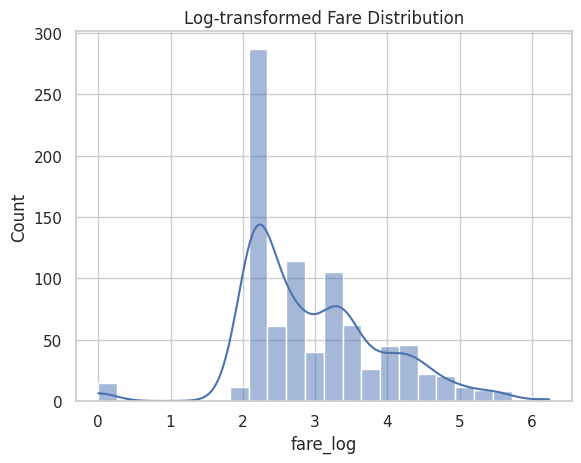

Columns after encoding:
['survived', 'name', 'sex', 'age', 'siblings/spouses', 'parents/children', 'fare', 'sibspouse', 'parentchild', 'fare_log', 'pclass_2', 'pclass_3']


In [6]:
# Binary indicators for family presence
df['sibspouse'] = (df['siblings/spouses'] > 0).astype(int)
df['parentchild'] = (df['parents/children'] > 0).astype(int)

# Encode sex: male=0, female=1
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

# Log-transform fare to handle skew (add 1 to avoid log(0))
df['fare_log'] = np.log1p(df['fare'])

# One-hot encode passenger class with drop_first=True
# This avoids the dummy variable trap (perfect multicollinearity)
# pclass_1 is dropped (reference); pclass_2 and pclass_3 are the dummy columns
df = pd.get_dummies(df, columns=['pclass'], prefix='pclass', drop_first=True)

sns.histplot(df['fare_log'], kde=True)
plt.title('Log-transformed Fare Distribution')
plt.show()

print("Columns after encoding:")
print(df.columns.tolist())

### Train-Test Split

We split the data into a training set (to teach the model) and a test set (to evaluate its performance on unseen data). We use **stratification** to preserve the class ratio in both splits.

In [7]:
# With drop_first=True, pclass_1 is the reference. pclass_2 and pclass_3 are the dummy columns.
features = ['age', 'sibspouse', 'parentchild', 'fare_log', 'sex', 'pclass_2', 'pclass_3']
X = df[features]
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples ({y_train.mean():.1%} survived)")
print(f"Test set:     {X_test.shape[0]} samples ({y_test.mean():.1%} survived)")

Training set: 665 samples (38.5% survived)
Test set:     222 samples (38.7% survived)


### Building the Pipeline

We use a `Pipeline` to chain preprocessing and modeling together. This ensures that transformations like scaling are applied consistently and prevents data leakage from the test set into training.

**Why scale features?** Logistic regression uses gradient descent to find optimal coefficients. When features are on different scales (e.g., age is 0–80, fare_log is 0–5), the optimization path becomes inefficient. `StandardScaler` centers each feature at mean=0 with unit variance, helping the solver converge faster and more stably.

**What is `remainder='passthrough'`?** The `ColumnTransformer` applies `StandardScaler` only to the continuous columns listed in `numeric_features`. Setting `remainder='passthrough'` tells it to pass all other columns (our binary-encoded features: sex, sibspouse, parentchild, pclass_2, pclass_3) through untouched. Without this, those columns would be silently dropped. Scaling binary (0/1) columns is unnecessary and can actually harm interpretability, so we leave them as-is.

Note: tree-based models like XGBoost don't need scaling because they make threshold-based splits rather than distance calculations.

In [8]:
numeric_features = ['age', 'fare_log']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ],
    remainder='passthrough'
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

pipeline.fit(X_train, y_train)

train_acc = pipeline.score(X_train, y_train)
test_acc = pipeline.score(X_test, y_test)
print(f"Training Accuracy: {train_acc:.3f}")
print(f"Testing Accuracy:  {test_acc:.3f}")

Training Accuracy: 0.809
Testing Accuracy:  0.770


### Cross-Validation: Is Our Model Stable?

The accuracy on our single test set is useful, but it can be influenced by how the data happened to be split. **K-Fold Cross-Validation** provides a more robust estimate of model performance by splitting the training data into $K$ subsets (folds). The model is trained $K$ times, each time using a different fold as the validation set and the remaining folds for training.

This helps us understand if our model is consistent or if its performance varies significantly depending on the data it sees.

In [9]:
# Perform 5-fold cross-validation on the training set
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')

print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

Cross-Validation Accuracy Scores: [0.79699248 0.78195489 0.84210526 0.82706767 0.7443609 ]
Mean CV Accuracy: 0.798 (+/- 0.069)


### How Good Is 77%? Establishing a Baseline

An accuracy of 77% might sound decent, but we need to compare against simple baselines to know if our model is actually adding value.

In [10]:
# Baseline 1: Always predict the majority class (died)
baseline_all_died = max(y_test.mean(), 1 - y_test.mean())

# Baseline 2: Simple rule - all women survive, all men die
X_test_gender = X_test.copy()
baseline_gender_pred = (X_test_gender['sex'] == 1).astype(int)
baseline_gender_acc = (baseline_gender_pred == y_test).mean()

print(f"Our model accuracy:              {test_acc:.3f}")
print(f"Baseline (predict all died):     {baseline_all_died:.3f}")
print(f"Baseline (women survive rule):   {baseline_gender_acc:.3f}")
print(f"\nOur model improves over the 'all died' baseline by {test_acc - baseline_all_died:.1%}")

Our model accuracy:              0.770
Baseline (predict all died):     0.613
Baseline (women survive rule):   0.770

Our model improves over the 'all died' baseline by 15.8%


### Reading the Baselines

Three models, stacked from simplest to most sophisticated:

| Model | Accuracy | What it uses |
|---|---|---|
| Always predict 'Died' | ~61% | Nothing — just the majority class |
| Women survive, men die | ~77% | One feature (sex) |
| Our logistic regression | ~77% | Seven features |

The single-feature gender rule is remarkably competitive — on this test set it actually *ties* our seven-feature model on accuracy. That tells us two things: (1) sex is genuinely dominant in this dataset, and (2) the other six features add almost nothing to *hard-label accuracy* beyond that single rule.

So is the model useless? No — accuracy is a blunt instrument here. The gender rule can only output "survived" or "died." The logistic regression produces a *probability* for every passenger, and those probabilities rank passengers well (the AUC of ~0.84 we compute below is something a one-feature yes/no rule cannot achieve). The model's value shows up in its probability estimates, its threshold flexibility, and its per-feature explanations — not in raw accuracy. It is also an honest caution worth remembering: when one feature dominates a dataset, more sophisticated models add less than you might hope.

### Interpreting the Model: Odds Ratios

The coefficients in a logistic regression model represent log-odds. To make them more intuitive, we exponentiate them to get **odds ratios**. An odds ratio greater than 1 means the feature increases the odds of survival; less than 1 means it decreases them.

In [11]:
# Get feature names from the preprocessor to ensure they match the coefficients
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
# Clean up the names (remove the 'num__' and 'remainder__' prefixes)
feature_names = [name.split('__')[-1] for name in feature_names]

coefficients = pipeline.named_steps['classifier'].coef_[0]
betas = pd.DataFrame({'feature': feature_names, 'beta': coefficients})
betas['odds_ratio'] = np.exp(betas['beta'])
betas.sort_values(by='odds_ratio', ascending=False)

,feature,beta,odds_ratio
4,sex,2.508220,12.283046
1,fare_log,0.315762,1.371304
3,parentchild,-0.228368,0.795832
2,sibspouse,-0.449889,0.637699
0,age,-0.534454,0.585989
5,pclass_2,-0.684171,0.504508
6,pclass_3,-1.784857,0.167821


**Key takeaways:**

- **Sex dominates**: being female increases the odds of survival by roughly 12x, all else equal
- **Age** decreases survival odds: older passengers were less likely to survive
- **Pclass_1** is the reference category (dropped by `drop_first=True`). Both `pclass_2` and `pclass_3` have odds ratios below 1, meaning 2nd and 3rd class passengers had lower survival odds than 1st class
- Higher **fares** increased survival odds
- Having **family members aboard** (siblings, spouses, parents, or children) generally correlated with lower survival odds for individuals, all else equal

Note: odds ratios tell us **direction and magnitude** of effect, but not statistical significance. For confidence intervals and p-values, we'd use `statsmodels`.

### Understanding Predicted Probabilities

Logistic regression produces probabilities, not just hard labels. Let's examine the distribution of predicted probabilities for passengers who actually died vs. survived.

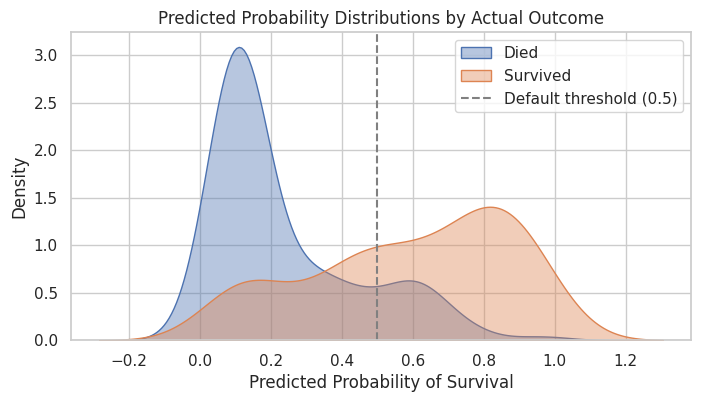

In [12]:
y_proba = pipeline.predict_proba(X_test)[:, 1]

plt.figure(figsize=(8, 4))
for survived in [0, 1]:
    sns.kdeplot(y_proba[y_test == survived],
                label=f"{'Died' if survived == 0 else 'Survived'}",
                fill=True, alpha=0.4)
plt.axvline(0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
plt.xlabel('Predicted Probability of Survival')
plt.ylabel('Density')
plt.title('Predicted Probability Distributions by Actual Outcome')
plt.legend()
plt.show()

### Model Evaluation: Classification Report

Accuracy alone doesn't tell the full story. The classification report gives us per-class metrics:
- **Precision**: When the model predicts "Survived", how often is it correct?
- **Recall**: Of all actual survivors, what fraction did the model catch?
- **F1-score**: Harmonic mean of precision and recall

Classification Report:
              precision    recall  f1-score   support

        Died       0.79      0.85      0.82       136
    Survived       0.73      0.64      0.68        86

    accuracy                           0.77       222
   macro avg       0.76      0.75      0.75       222
weighted avg       0.77      0.77      0.77       222


Confusion Matrix:


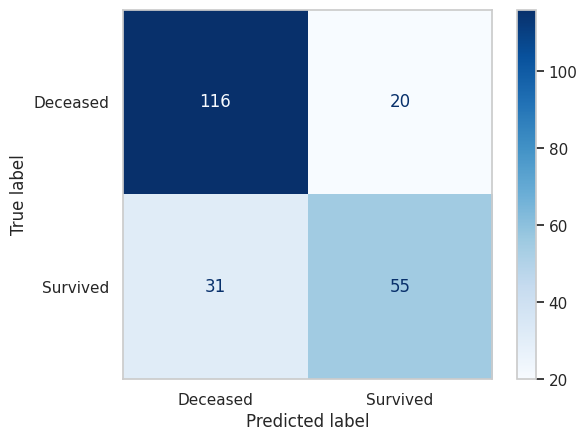

In [13]:
y_pred = pipeline.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Died', 'Survived']))

print("\nConfusion Matrix:")
disp = ConfusionMatrixDisplay.from_estimator(
    pipeline, X_test, y_test, cmap='Blues',
    display_labels=['Deceased', 'Survived']
)
plt.grid(False)
plt.show()

**Reading the report:**

- For "Died" (class 0): precision=0.79, recall=0.85, we correctly identified 85% of actual deaths
- For "Survived" (class 1): precision=0.73, recall=0.64, we caught 64% of actual survivors
- The model is better at predicting death than survival, partly because the class is larger (imbalance)
- Look at the confusion matrix: the off-diagonal cells show how many survivors we missed (false negatives) and how many deaths we falsely predicted as survival (false positives)

**Which error is worse on the Titanic?** Falsely telling someone their loved one survived when they died (FN), or falsely reporting a death (FP)? This is a context-dependent question, there's no single right answer.

### ROC Curve and AUC

The **ROC curve** plots the True Positive Rate (recall) against the False Positive Rate at every possible threshold. **AUC** (Area Under the Curve) measures the model's ability to rank positive instances above negative ones. AUC=0.5 is random; AUC=1.0 is perfect.

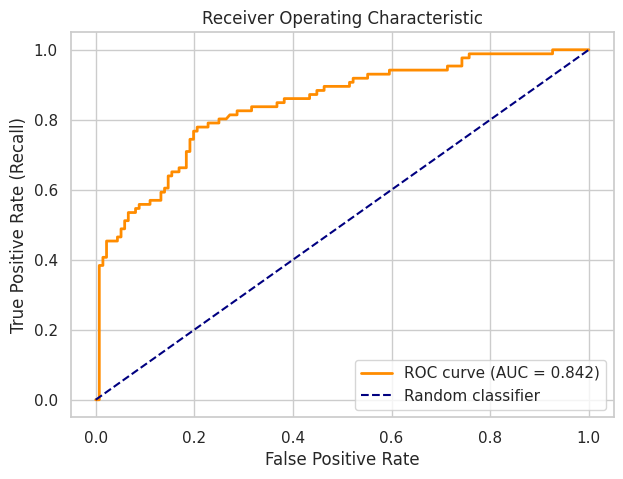

AUC: 0.842
Interpretation: there is a 84.2% chance the model will rank a random survivor above a random non-survivor.


In [14]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic')
plt.legend()
plt.grid(True)
plt.show()

print(f"AUC: {roc_auc:.3f}")
print(f"Interpretation: there is a {roc_auc:.1%} chance the model will rank a random survivor above a random non-survivor.")

### Precision-Recall Curve

While the ROC curve is excellent for balanced datasets, the **Precision-Recall (PR) curve** is often more informative when dealing with class imbalance. It focuses on the performance of the positive class (survivors).

A PR curve plots precision vs. recall for different thresholds. The **Average Precision (AP)** summarizes the curve as the weighted mean of precisions achieved at each threshold.

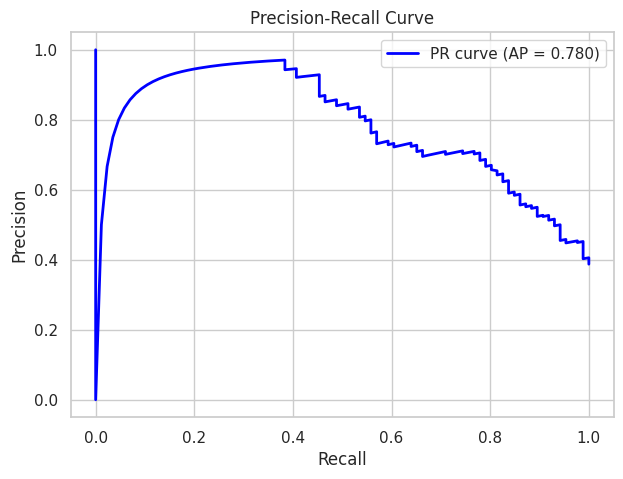

Average Precision: 0.780


In [15]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AP = {avg_precision:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

print(f"Average Precision: {avg_precision:.3f}")

### Threshold Tuning

The default decision threshold is 0.5, but we can adjust it depending on our priorities. Lowering the threshold catches more survivors (higher recall) but increases false positives (lower precision). Raising it does the opposite.

> **Connecting to Module 18_1:** The Youden's J statistic and business cost curve methods from Notebooks 18_1_4 and 18_1_5 apply directly here. Those tools work on any model that produces probabilities — XGBoost, logistic regression, or anything else. If you need a principled threshold rather than a manual sweep, go back to that framework.

Here we do a quick manual sweep to see the precision-recall trade-off in action.

In [16]:
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]
results = []

for t in thresholds_to_test:
    y_pred_t = (y_proba >= t).astype(int)
    results.append({
        'Threshold': t,
        'Accuracy': accuracy_score(y_test, y_pred_t),
        'Precision': precision_score(y_test, y_pred_t),
        'Recall': recall_score(y_test, y_pred_t)
    })

pd.DataFrame(results).set_index('Threshold').round(3)

,Accuracy,Precision,Recall
Threshold,,,
0.3,0.757,0.648,0.814
0.4,0.784,0.702,0.767
0.5,0.770,0.733,0.640
0.6,0.770,0.797,0.547
0.7,0.770,0.927,0.442


**Observations:**
- At **t=0.3**: recall is 0.81 (we catch most survivors), but precision drops to 0.65 (more false alarms)
- At **t=0.4**: accuracy peaks at 0.78 — the best balance for this dataset with equal error costs
- At **t=0.7**: precision reaches 0.93, but recall plummets to 0.44 (we miss over half the survivors)
- No single threshold is "best" — it depends on the cost of each error type

In a real application, you'd choose the threshold that minimizes expected cost, using business context to assign dollar values to false positives and false negatives.

## When to Choose Logistic Regression

Our model just achieved AUC ≈ 0.84. XGBoost on the same Titanic data achieves roughly the same. Given that XGBoost often outperforms LR on complex tabular data, when would you deliberately choose the simpler model?

**1. You need to explain individual decisions.**
A bank denying a loan application must be able to explain exactly why — this is a legal requirement in many jurisdictions (GDPR, ECOA, FCRA). LR's coefficients make that possible: *'Your application was declined primarily because your debt-to-income ratio exceeds the threshold by 2.1 standard deviations, reducing your approval odds by a factor of 0.23.'* XGBoost cannot produce an equivalent statement.

**2. Your relationships are approximately linear in the log-odds.**
LR assumes a linear relationship between features and log-odds. When this holds — which it often does for well-engineered features on structured data — LR is surprisingly competitive. On the Titanic, the dominant signal (sex) is binary and LR captures it perfectly.

**3. You need well-calibrated probabilities.**
LR's predicted probabilities are naturally calibrated: if it says 70%, roughly 70% of those cases are actually positive. XGBoost often requires post-hoc calibration (Platt scaling). Calibration matters whenever the probability itself — not just the label — drives a real-world decision.

**4. You are working with limited data.**
LR has far fewer parameters than a boosted ensemble. On datasets with hundreds rather than thousands of samples, LR is less prone to overfitting. The hawk dataset in the archived notebook (65 birds) is a good example of this regime.

**5. Inference speed or deployment constraints.**
LR inference is a dot product and one function call — microseconds per prediction. At millions of inferences per second (fraud scoring, real-time bidding), this is non-trivial.

---

The next notebook (18_2_2) looks at interpretability in depth: confidence intervals on coefficients, a visual comparison of LR vs. XGBoost explanations on the same data, and the kinds of questions each model can and cannot answer.

## Summary

In this notebook you:

1. Learned that the **sigmoid function** squashes a linear combination of features into a probability in (0, 1).
2. Saw that **logistic regression is a single artificial neuron** — the fundamental unit of every neural network, with the same weighted sum, bias, and activation structure.
3. Built a **logistic regression pipeline** using `ColumnTransformer` + `Pipeline` to prevent data leakage and handle mixed feature types correctly.
4. Interpreted coefficients as **odds ratios**: exponentiate the coefficient to see how much a one-unit change in a feature multiplies the odds of the outcome.
5. Evaluated the model with precision, recall, F1, AUC, and threshold sweeping — the same toolkit from Module 18_1 applies here.
6. Built the argument for **when to prefer LR over XGBoost**: interpretability requirements, approximate linearity, calibrated probabilities, small data, or speed constraints.

**Up next:** Notebook 18_2_2 examines interpretability more rigorously — odds ratio confidence intervals, the XGBoost comparison, and the scenarios where interpretability is not optional.

## Problems

### Problem 1
Explain precision, recall, and F1 score. Be clear and precise about what each one measures.

Write your answer here.

### Problem 2
Look at the classification report for our model. Explain what the precision, recall, and F1 values mean in terms of our model's performance on the Titanic survival prediction task. Which class does the model handle better and why?

Write your answer here.

### Problem 3
Find the best logistic regression model using only **four features** from the original set. You can use any approach: exhaustive search over feature combinations, L1 regularization, or forward/backward selection.

**Hint:** If you want to try L1 regularization, set `penalty='l1'` and `solver='liblinear'` in your LogisticRegression. The `C` parameter controls regularization strength (smaller C = more regularization, more features pushed to zero).

**Hint for exhaustive search:** The `itertools.combinations` module can generate all 4-feature subsets. Loop through them and track the best test accuracy.

In [17]:
# Enter your code here
# Try finding the best 4-feature logistic regression model




### Problem 4
Explain your solution to Problem 3. What approach did you use? What was the best 4-feature set you found, and how did you determine it was the best? How does the 4-feature model's performance compare to the full 7-feature model?

Write your answer here.